# Cascading Failures in Power Grids: A Dynamic Simulation

**Emily Earl**

When a heavily loaded power line fails, its power has to reroute through the rest of the network. That can overload other lines, which trip in turn, and a single fault can spread into a blackout. This notebook asks:

- **How much spare capacity do lines need** before the failure of the most loaded line stops spreading?
- **Does network structure matter?** Are ordered, lattice-like grids more or less resilient than randomly wired ones?
- **Does network size matter?**

The cascade is simulated *dynamically*. Rather than jumping straight to the new steady state after each failure, the swing equations are integrated through the transient, and a line trips the moment its flow exceeds its capacity. This captures the temporary overshoot in flow that a static calculation misses.

*This analysis was my contribution to a group project on power-grid stability.*

## Model

Each node $k$ is a generator ($P_k = +1$) or consumer ($P_k = -1$), with equal numbers of each. Phase angles follow the swing equation

$$\ddot\theta_k + \gamma\dot\theta_k = P_k - \kappa\sum_l A_{kl}\sin(\theta_k - \theta_l),$$

where $A$ is the adjacency matrix, $\gamma$ the damping and $\kappa$ the coupling strength. The power flow on line $(k,l)$ is $f_{kl} = \kappa\sin(\theta_k - \theta_l)$.

Networks are **Watts–Strogatz** graphs: each node starts connected to its 4 nearest neighbours on a ring, and each line is rewired at random with probability $q$. So $q = 0$ is an ordered ring lattice, $q = 1$ is essentially random, and $q = 0.1$ is a "small world" in between.

**The cascade experiment:**
1. Find the synchronised steady state and its largest line flow $\alpha^*$.
2. Give every line the capacity $\alpha = (\alpha/\alpha^*) \times \alpha^*$. The ratio $\alpha/\alpha^*$ is the tolerance being varied, where 1 means capacity exactly equal to the largest steady flow.
3. Remove the most loaded line.
4. Integrate the dynamics. At the first moment any line's flow exceeds $\alpha$ (or any node's frequency exceeds $2\pi$), those elements fail. Restart from that moment with them removed.
5. Repeat until a full integration window passes with no new failures.

In [1]:
import numpy as np
import networkx as nx
from scipy.integrate import solve_ivp

## Parameters

In [2]:
MEAN_DEGREE = 4
GAMMA = 1.0          # damping
KAPPA = 5.0          # coupling strength
P_VALUE = 1.0        # generator / consumer power magnitude
T_MAX = 100.0        # integration window
DT = 0.05            # time resolution for failure checks
EPS_SYNC = 1e-3      # steady-state frequency tolerance
OMEGA_MAX = 2 * np.pi
MAX_ROUNDS = 200

## Network and power assignment

In [3]:
def generate_ws_network(n, mean_degree, q, seed=None):
    G = nx.connected_watts_strogatz_graph(n, mean_degree, q, tries=1000, seed=seed)
    A = nx.to_numpy_array(G)
    edges = [(int(u), int(v)) if u < v else (int(v), int(u)) for u, v in G.edges()]
    return G, A, edges


def assign_balanced_power(n, P=1.0, seed=None):
    if n % 2:
        raise ValueError("n must be even for balanced power assignment")
    rng = np.random.default_rng(seed)
    P_vec = -P * np.ones(n)
    P_vec[rng.choice(n, size=n // 2, replace=False)] = P
    return P_vec

## Swing-equation dynamics and steady state

The steady state starts from angles near zero. Random starting angles can lock ring networks into 'twisted' states with unusually large flows.

In [4]:
def swing_equations(t, x, P, A, gamma, kappa):
    n = len(P)
    theta, omega = x[:n], x[n:]
    coupling = (A * np.sin(theta[:, None] - theta[None, :])).sum(axis=1)
    return np.concatenate([omega, P - gamma * omega - kappa * coupling])


def integrate_swing(x0, P, A, gamma=GAMMA, kappa=KAPPA, T_max=T_MAX, dt=DT):
    t_eval = np.arange(0, T_max + dt / 2, dt)
    return solve_ivp(swing_equations, (0, T_max), x0, t_eval=t_eval,
                     args=(P, A, gamma, kappa), rtol=1e-6, atol=1e-8)


def find_steady_state(A, P, seed=None):
    n = len(P)
    rng = np.random.default_rng(seed)
    x0 = np.concatenate([rng.uniform(-0.1, 0.1, n), np.zeros(n)])
    sol = integrate_swing(x0, P, A)
    theta, omega = sol.y[:n, -1], sol.y[n:, -1]
    if np.max(np.abs(omega)) >= EPS_SYNC:
        return None
    return theta, omega

## Line flows and removal

In [5]:
def edge_flows(theta, edges, kappa=KAPPA):
    k, l = np.array(edges).T
    return kappa * np.sin(theta[k] - theta[l])


def remove_edges(A, edges, failed):
    A = A.copy()
    for k, l in failed:
        A[k, l] = A[l, k] = 0
    failed = set(failed)
    return A, [e for e in edges if e not in failed]


def remove_nodes(A, edges, failed_nodes):
    A = A.copy()
    A[failed_nodes, :] = 0
    A[:, failed_nodes] = 0
    bad = set(failed_nodes)
    return A, [e for e in edges if e[0] not in bad and e[1] not in bad]

## The cascade

`cascade_step` integrates the dynamics and finds the **first moment** any line or node exceeds its limit. The next round restarts from the state at that moment, because after a line trips it no longer carries power.

In [6]:
def cascade_step(x0, A, edges, P, alpha):
    n = len(P)
    sol = integrate_swing(x0, P, A)
    theta, omega = sol.y[:n], sol.y[n:]
    if edges:
        k, l = np.array(edges).T
        overload = np.abs(KAPPA * np.sin(theta[k] - theta[l])) > alpha     # edges x times
    else:
        overload = np.zeros((0, theta.shape[1]), dtype=bool)
    desync = np.abs(omega) > OMEGA_MAX                                      # nodes x times
    any_fail = overload.any(axis=0) | desync.any(axis=0)
    if not any_fail.any():
        return sol.y[:, -1], [], []
    t_fail = int(np.argmax(any_fail))                   # first moment anything fails
    failed_edges = [edges[i] for i in np.where(overload[:, t_fail])[0]]
    failed_nodes = list(np.where(desync[:, t_fail])[0])
    return sol.y[:, t_fail], failed_edges, failed_nodes  # restart from the moment of failure


def run_cascade(A, edges, x0, P, alpha):
    A, edges, x = A.copy(), list(edges), x0.copy()
    history = []
    for _ in range(MAX_ROUNDS):
        x, failed_edges, failed_nodes = cascade_step(x, A, edges, P, alpha)
        history.append(dict(failed_edges=len(failed_edges), failed_nodes=len(failed_nodes),
                            edges_before=len(edges)))
        if not failed_edges and not failed_nodes:
            return A, edges, x, history, "no_new_failures"
        A, edges = remove_edges(A, edges, failed_edges)
        if failed_nodes:
            A, edges = remove_nodes(A, edges, failed_nodes)
        if not edges:
            return A, edges, x, history, "no_edges_remaining"
    return A, edges, x, history, "max_rounds"

## Measuring resilience: two bounds

After a cascade the network may have split into islands. Counting surviving lines is not the whole story. An island whose generators and consumers no longer balance cannot hold the grid frequency on its own, even though its lines are intact. So each experiment reports two numbers:

- **Upper bound, $S$:** the fraction of lines still connected.
- **Lower bound, $S_{\rm bal}$:** the fraction of lines in islands where generation still equals demand, which can run at the nominal frequency without outside support.

A real grid lies between them, depending on how much imbalance its frequency control can absorb. The lower bound is deliberately strict: disconnecting a single node leaves the main island one unit out of balance, and all of its lines then count as lost.

In [7]:
def run_single_experiment(n, q, alpha_ratio, seed):
    G, A, edges = generate_ws_network(n, MEAN_DEGREE, q, seed=seed)
    P = assign_balanced_power(n, P_VALUE, seed=seed)
    steady = find_steady_state(A, P, seed=seed)
    if steady is None:
        return None
    theta_star, omega_star = steady
    flows = edge_flows(theta_star, edges)
    alpha_star = np.max(np.abs(flows))
    trigger = edges[int(np.argmax(np.abs(flows)))]        # most loaded line fails first
    A0, edges0 = remove_edges(A, edges, [trigger])
    x0 = np.concatenate([theta_star, omega_star])
    A_f, edges_f, x_f, history, reason = run_cascade(A0, edges0, x0, P, alpha_ratio * alpha_star)
    # Upper bound: every line still connected counts as surviving.
    # Lower bound: only lines in islands whose generation and demand still balance,
    # i.e. islands that can hold the nominal frequency without outside support.
    Gf = nx.Graph(); Gf.add_nodes_from(range(n)); Gf.add_edges_from(edges_f)
    balanced_edges = sum(Gf.subgraph(c).number_of_edges()
                         for c in nx.connected_components(Gf) if abs(P[list(c)].sum()) < 1e-9)
    return dict(n=n, q=q, alpha_ratio=alpha_ratio, seed=seed,
                S=len(edges_f) / len(edges), S_bal=balanced_edges / len(edges),
                rounds=len(history), reason=reason)

---
## Worked example: one network, one fault

Largest steady flow alpha* = 0.836 on line (1, 3)


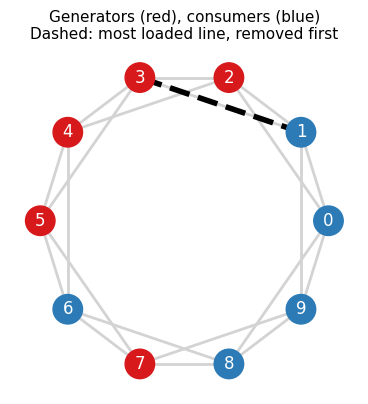

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import os
os.makedirs('figures', exist_ok=True)

n_ex, q_ex, seed_ex = 10, 0.1, 0
G_ex, A_ex, edges_ex = generate_ws_network(n_ex, MEAN_DEGREE, q_ex, seed=seed_ex)
P_ex = assign_balanced_power(n_ex, P_VALUE, seed=seed_ex)
theta_ex, omega_ex = find_steady_state(A_ex, P_ex, seed=seed_ex)
flows_ex = edge_flows(theta_ex, edges_ex)
alpha_star_ex = np.max(np.abs(flows_ex))
trigger_ex = edges_ex[int(np.argmax(np.abs(flows_ex)))]
print(f"Largest steady flow alpha* = {alpha_star_ex:.3f} on line {trigger_ex}")

pos = nx.circular_layout(G_ex)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
nx.draw_networkx_edges(G_ex, pos, ax=ax, edge_color='lightgray', width=2)
nx.draw_networkx_edges(G_ex, pos, edgelist=[trigger_ex], ax=ax, edge_color='black', width=4, style='dashed')
nx.draw_networkx_nodes(G_ex, pos, ax=ax, node_color=['#d7191c' if p > 0 else '#2c7bb6' for p in P_ex], node_size=450)
nx.draw_networkx_labels(G_ex, pos, ax=ax, font_color='white')
ax.set_title('Generators (red), consumers (blue)\nDashed: most loaded line, removed first', fontsize=11)
ax.axis('off')
plt.savefig('figures/fig1_example_network.png', dpi=150, bbox_inches='tight')
plt.show()

After the most loaded line is removed, its power reroutes. The plot below shows every remaining line's flow relative to $\alpha^*$ during the transient that follows. Flows **overshoot** their new steady values, so a line can briefly exceed a capacity above $\alpha^*$ even if it would settle below it. A static calculation that only compares steady states would miss these failures.

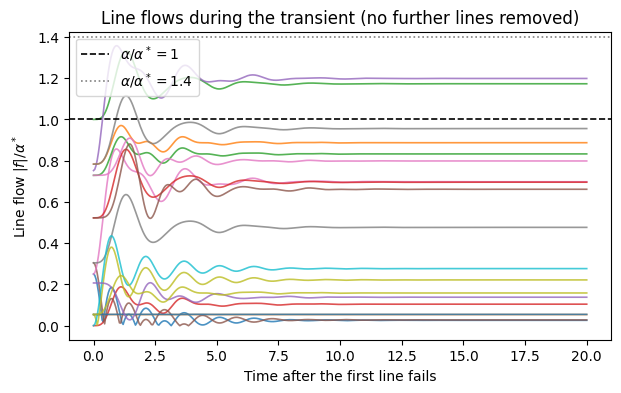

Peak transient flow: 1.36 x alpha*;  settled maximum: 1.20 x alpha*


In [9]:
A_after, edges_after = remove_edges(A_ex, edges_ex, [trigger_ex])
sol = integrate_swing(np.concatenate([theta_ex, omega_ex]), P_ex, A_after, T_max=20.0)
k, l = np.array(edges_after).T
rel_flow = np.abs(KAPPA * np.sin(sol.y[k] - sol.y[l])) / alpha_star_ex

fig, ax = plt.subplots(figsize=(7, 4))
for row in rel_flow:
    ax.plot(sol.t, row, lw=1.2, alpha=0.8)
ax.axhline(1.0, color='k', ls='--', lw=1.2, label=r'$\alpha/\alpha^* = 1$')
ax.axhline(1.4, color='gray', ls=':', lw=1.2, label=r'$\alpha/\alpha^* = 1.4$')
ax.set_xlabel('Time after the first line fails')
ax.set_ylabel(r'Line flow $|f| / \alpha^*$')
ax.set_title('Line flows during the transient (no further lines removed)')
ax.legend()
plt.savefig('figures/fig2_transient_flows.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Peak transient flow: {rel_flow.max():.2f} x alpha*;  settled maximum: {rel_flow[:, -1].max():.2f} x alpha*")

In [10]:
x0 = np.concatenate([theta_ex, omega_ex])
_, edges_end, _, history, reason = run_cascade(A_after, edges_after, x0, P_ex, 1.0 * alpha_star_ex)
for i, h in enumerate(history):
    print(f"Round {i}: {h['failed_edges']} lines failed, {h['failed_nodes']} nodes failed, {h['edges_before']} lines at start")
print(f"\nEnded: {reason}.  Lines surviving: {len(edges_end)} of {len(edges_ex)}")

Round 0: 1 lines failed, 0 nodes failed, 19 lines at start
Round 1: 1 lines failed, 0 nodes failed, 18 lines at start
Round 2: 1 lines failed, 0 nodes failed, 17 lines at start
Round 3: 1 lines failed, 0 nodes failed, 16 lines at start
Round 4: 1 lines failed, 0 nodes failed, 15 lines at start
Round 5: 1 lines failed, 0 nodes failed, 14 lines at start
Round 6: 1 lines failed, 0 nodes failed, 13 lines at start
Round 7: 1 lines failed, 0 nodes failed, 12 lines at start
Round 8: 0 lines failed, 0 nodes failed, 11 lines at start

Ended: no_new_failures.  Lines surviving: 11 of 20


---
## Sweep: tolerance, structure and size

For each network size $n \in \{10, 50\}$, rewiring probability $q \in \{0, 0.1, 1\}$ and tolerance $\alpha/\alpha^* \in \{0.6, \ldots, 1.6\}$, 25 random networks are simulated, giving 900 cascades in total.

The full sweep takes 15–20 minutes on one CPU core, so results are saved to `results/cascade_sweep.csv`. Delete that file to recompute from scratch.

In [11]:
import itertools
RESULTS = 'results/cascade_sweep.csv'
N_VALUES, Q_VALUES = [10, 50], [0.0, 0.1, 1.0]
ALPHA_RATIOS = np.round(np.linspace(0.6, 1.6, 6), 2)
N_TRIALS = 25

if os.path.exists(RESULTS):
    df = pd.read_csv(RESULTS)
    print(f"Loaded {len(df)} saved results from {RESULTS}")
else:
    rows = []
    for n, q, a, s in itertools.product(N_VALUES, Q_VALUES, ALPHA_RATIOS, range(N_TRIALS)):
        r = run_single_experiment(n, q, a, s)
        rows.append(r if r else dict(n=n, q=q, alpha_ratio=a, seed=s, S=np.nan, S_bal=np.nan,
                                     rounds=np.nan, reason='not_synchronised'))
    df = pd.DataFrame(rows)
    os.makedirs('results', exist_ok=True)
    df.to_csv(RESULTS, index=False)

print(df['reason'].value_counts().to_string())

Loaded 900 saved results from results/cascade_sweep.csv
reason
no_new_failures    900


In [12]:
summary = (df.groupby(['n', 'q', 'alpha_ratio'])
             .agg(S=('S', 'mean'), S_se=('S', 'sem'), S_bal=('S_bal', 'mean'),
                  S_bal_se=('S_bal', 'sem'), rounds=('rounds', 'mean'))
             .reset_index())
summary.round(2)

,n,q,alpha_ratio,S,S_se,S_bal,S_bal_se,rounds
0,10,0.0,0.6,0.44,0.02,0.00,0.00,3.88
1,10,0.0,0.8,0.48,0.03,0.00,0.00,5.76
2,10,0.0,1.0,0.42,0.03,0.00,0.00,10.52
3,10,0.0,1.2,0.40,0.02,0.00,0.00,10.44
4,10,0.0,1.4,0.69,0.06,0.49,0.10,5.48
5,10,0.0,1.6,0.95,0.00,0.95,0.00,1.00
6,10,0.1,0.6,0.44,0.02,0.00,0.00,4.36
7,10,0.1,0.8,0.43,0.02,0.00,0.00,7.48
8,10,0.1,1.0,0.42,0.03,0.00,0.00,9.92
9,10,0.1,1.2,0.45,0.04,0.00,0.00,9.80


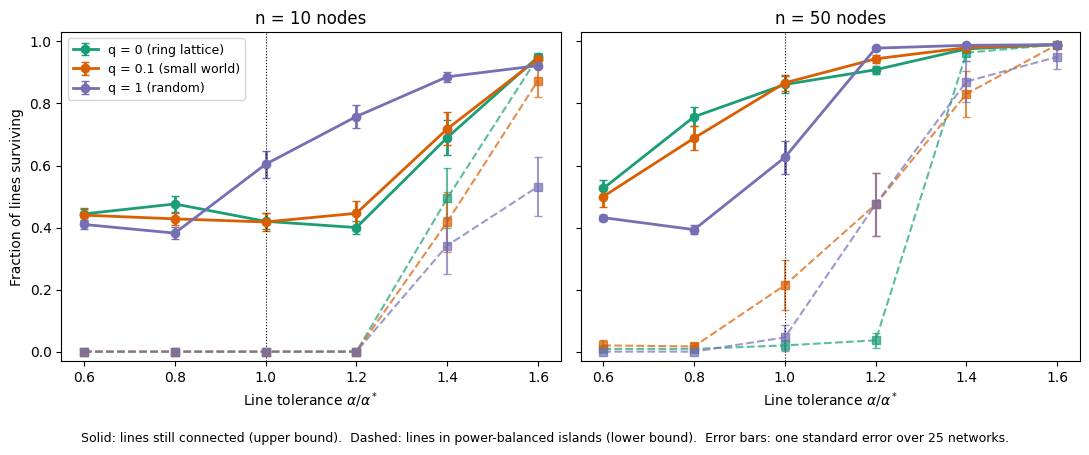

In [13]:
colours = {0.0: '#1b9e77', 0.1: '#d95f02', 1.0: '#7570b3'}
labels = {0.0: 'q = 0 (ring lattice)', 0.1: 'q = 0.1 (small world)', 1.0: 'q = 1 (random)'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, n in zip(axes, N_VALUES):
    for q in Q_VALUES:
        d = summary[(summary.n == n) & (summary.q == q)]
        ax.errorbar(d.alpha_ratio, d.S, yerr=d.S_se, marker='o', color=colours[q], lw=2, capsize=3, label=labels[q])
        ax.errorbar(d.alpha_ratio, d.S_bal, yerr=d.S_bal_se, marker='s', ls='--', color=colours[q], lw=1.5, capsize=3, alpha=0.7)
    ax.axvline(1.0, color='k', lw=0.8, ls=':')
    ax.set_title(f'n = {n} nodes')
    ax.set_xlabel(r'Line tolerance $\alpha/\alpha^*$')
    ax.set_ylim(-0.03, 1.03)
axes[0].set_ylabel('Fraction of lines surviving')
axes[0].legend(loc='upper left', fontsize=9)
fig.text(0.5, -0.04, 'Solid: lines still connected (upper bound).  Dashed: lines in power-balanced islands (lower bound).  '
         'Error bars: one standard error over 25 networks.', ha='center', fontsize=9)
fig.tight_layout()
plt.savefig('figures/fig3_resilience_vs_tolerance.png', dpi=150, bbox_inches='tight')
plt.show()

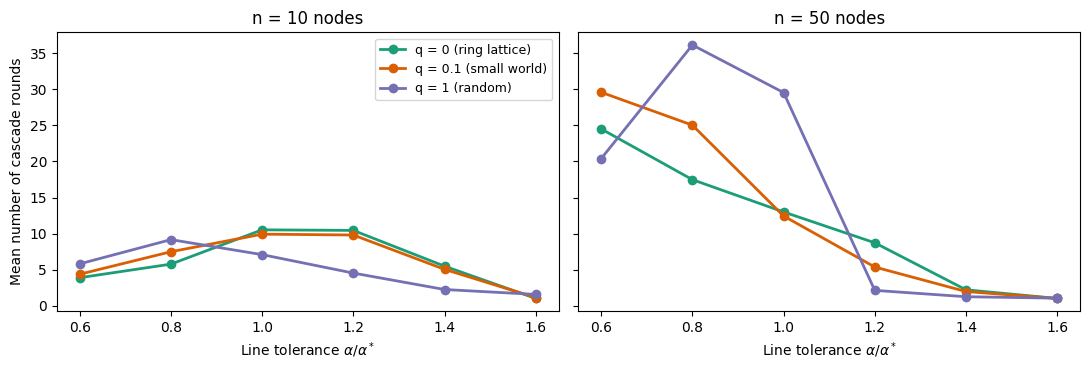

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, n in zip(axes, N_VALUES):
    for q in Q_VALUES:
        d = summary[(summary.n == n) & (summary.q == q)]
        ax.plot(d.alpha_ratio, d.rounds, marker='o', color=colours[q], lw=2, label=labels[q])
    ax.set_title(f'n = {n} nodes')
    ax.set_xlabel(r'Line tolerance $\alpha/\alpha^*$')
axes[0].set_ylabel('Mean number of cascade rounds')
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.savefig('figures/fig4_cascade_rounds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Findings

**1. Lines need 40–60% spare capacity above the largest normal flow to stop the cascade.** Even when every line can carry 20% more than the largest steady-state flow ($\alpha/\alpha^* = 1.2$), cascades still spread in most networks. They reliably stop after the first failure only at around $\alpha/\alpha^* = 1.4$–$1.6$. The worked example shows why. Once the most loaded line fails, its power reroutes, and the new steady flows are higher than before (1.20× the old maximum in that network). During the transient they briefly overshoot further (1.36×). A static calculation catches the first effect but misses the second.

**2. Intact lines overstate how much of the grid survives.** The two bounds are far apart. For example, in 50-node ring lattices at $\alpha/\alpha^* = 1.2$, about 91% of lines stay connected, but only about 4% are in islands whose power still balances. Usually a handful of nodes have been cut off, leaving the main island slightly out of balance. How much this matters in practice depends on the grid's frequency control, but counting intact lines alone hides it.

**3. The effect of structure depends on how stressed the lines are.** In 50-node networks with tight tolerances ($\alpha/\alpha^* \le 0.8$), ordered ring lattices keep more lines connected than random networks (for example 76% against 39% at 0.8). At looser tolerances ($\alpha/\alpha^* = 1.2$) the order reverses: random networks are the most intact (98%, against 91% for rings). Small-world networks sit between the two on the upper bound, but have the highest lower bound at $\alpha/\alpha^* = 1.0$.

**4. Larger networks absorb a single failure better.** At $\alpha/\alpha^* = 1.2$, 50-node networks keep 91–98% of their lines connected, against 40–76% for 10-node networks. In a small network, one lost line is a large share of the total, and rerouted power has fewer alternative paths.

**5. Tight tolerances produce long, drawn-out cascades.** At $\alpha/\alpha^* \le 1.0$, cascades in 50-node networks last 12–36 rounds on average, with the longest in random networks at $\alpha/\alpha^* = 0.8$. Failures propagate one or two lines at a time rather than all at once. At $\alpha/\alpha^* \ge 1.4$, most cascades end within one or two rounds.

Differences smaller than about 0.1 in the surviving fraction are within the run-to-run noise (standard errors reach about 0.06 with 25 networks), so the comparisons above are the clear ones.

## Limitations

- Every node has the same power magnitude ($\pm 1$), damping and coupling, with no real grid data.
- A node fails only if its frequency exceeds $2\pi$, which in practice never happened in these runs. Loss of synchrony shows up instead through the lower bound $S_{\rm bal}$.
- Each tolerance setting uses 25 networks and only two network sizes.
- There is no frequency control or protection logic, such as load shedding or controlled islanding, which real grids use to limit cascades.